# Online Retail Customer Segmentation Using K-Means Clustering

## Project Overview

This project segments customers from the UCI Online Retail dataset using K-Means clustering.

The purpose is to identify distinct customer groups based on their purchasing behavior and translate these clusters into actionable business segments.

RFM (Recency, Frequency, Monetary) is used here as a feature-engineering framework rather than as the primary segmentation method. The main segmentation is performed using **K-Means clustering** on the transformed and standardized RFM features.

A separate RFM analysis is provided in the **Appendix** to compare a traditional rule-based approach with the ML segmentation.

# 1. Import Required Libraries

In [1]:
# Numerical computing and Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.cluster import KMeans

# Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Model saving
import joblib as jl
from pathlib import Path


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline

# 2. Load and Understand the Dataset

In [2]:
df=pd.read_excel("../data/Online Retail.xlsx") # Read the dataset
df.head() # Display the first five rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.tail() # Display the last five rows of the dataset

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
df.shape # Display the number of rows and columns in the dataset

(541909, 8)

In [5]:
df.info() # Display the summary of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
df.describe() # Display the statistical summary of the dataset

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# 3. Data Cleaning

In [7]:
df.duplicated().sum() # Check for duplicate rows in the dataset

np.int64(5268)

In [8]:
df.drop_duplicates(inplace=True) # Drop duplicate rows from the dataset

In [9]:
df.isnull().sum() # Check for missing values in the dataset

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [10]:
df.dropna(subset=['CustomerID', 'Description'], inplace=True) # Drop rows with missing values from the dataset

In [11]:
(df['UnitPrice'] <=0).sum()

np.int64(40)

In [12]:
(df['Quantity']<=0).sum()

np.int64(8872)

### Selecting only positive transactions

In [13]:
df=df[(df['UnitPrice']>0) & (df['Quantity']>0)]

In [14]:
df=df.reset_index(drop=True) # Create a copy of the cleaned dataset

Transactions with non-positive quantities or unit prices were kept out from the actual purchase-behavior analysis so returns, cancellations or invalid prices aren't taken as customer purchases data.

Extreme but valid customer behavior is retained because high spending or high purchase frequency may represent genuine high-value customers rather than data errors.

In [15]:
df.shape

(392692, 8)

### Create Revenue Feature

In [16]:
df['Revenue']=df['UnitPrice']*df['Quantity']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


# 4. Exploratory Data Analysis

In [17]:
df[['InvoiceNo','StockCode', 'CustomerID', 'Country']].nunique() # Check the number of unique invoices in the dataset

InvoiceNo     18532
StockCode      3665
CustomerID     4338
Country          37
dtype: int64

### Customer distribution

In [18]:
df['CustomerID'].value_counts().head(10) # Check the number of unique customers in the dataset

CustomerID
17841.0    7676
14911.0    5670
14096.0    5111
12748.0    4412
14606.0    2677
15311.0    2366
14646.0    2076
13089.0    1814
13263.0    1667
14298.0    1637
Name: count, dtype: int64

### Geographic distribution

In [19]:
df['Country'].value_counts().head(10) # Check the number of unique countries in the dataset

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

### Revenue trend

In [20]:
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
monthly_revenue

InvoiceDate
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

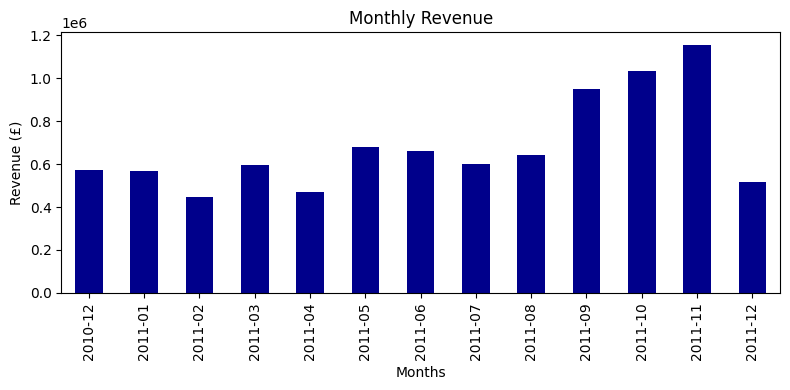

In [21]:
monthly_revenue.plot(kind='bar', figsize=(8,4), color='darkblue')
plt.title("Monthly Revenue")
plt.xlabel("Months")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

### Top Products by Revenue

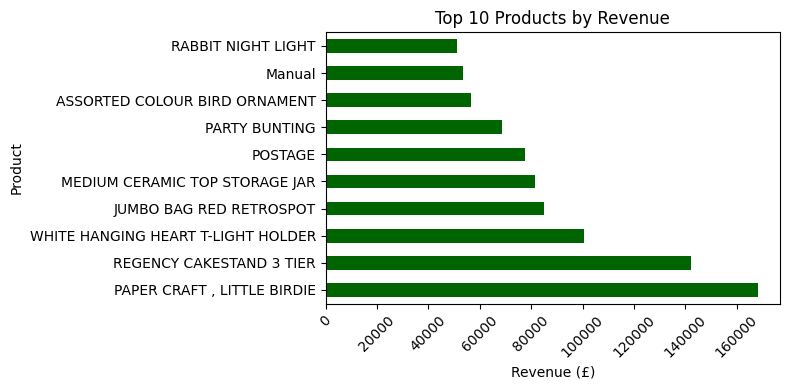

In [22]:
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,4), color='darkgreen')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis: 
Revenue is concentrated across a relatively small number of products and customers. Therefore, Customer behavior is suitable for segmentation based on purchasing patterns.

# 6. RFM Feature Engineering

### Reference date

In [23]:
reference_date=df['InvoiceDate'].max() + pd.DateOffset(days=1) # Set the reference date for RFM analysis

### Feature Definitions

- **Recency:** Days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices associated with the customer.
- **Monetary:** Total revenue generated by the customer.

In [24]:
rfm=df.groupby("CustomerID").agg(
    Recency=('InvoiceDate', lambda x: (reference_date-x.max()).days),
    Frequency=('InvoiceNo','nunique'),
    Monetary=('Revenue', 'sum')
    )

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### RFM Feature Distributions

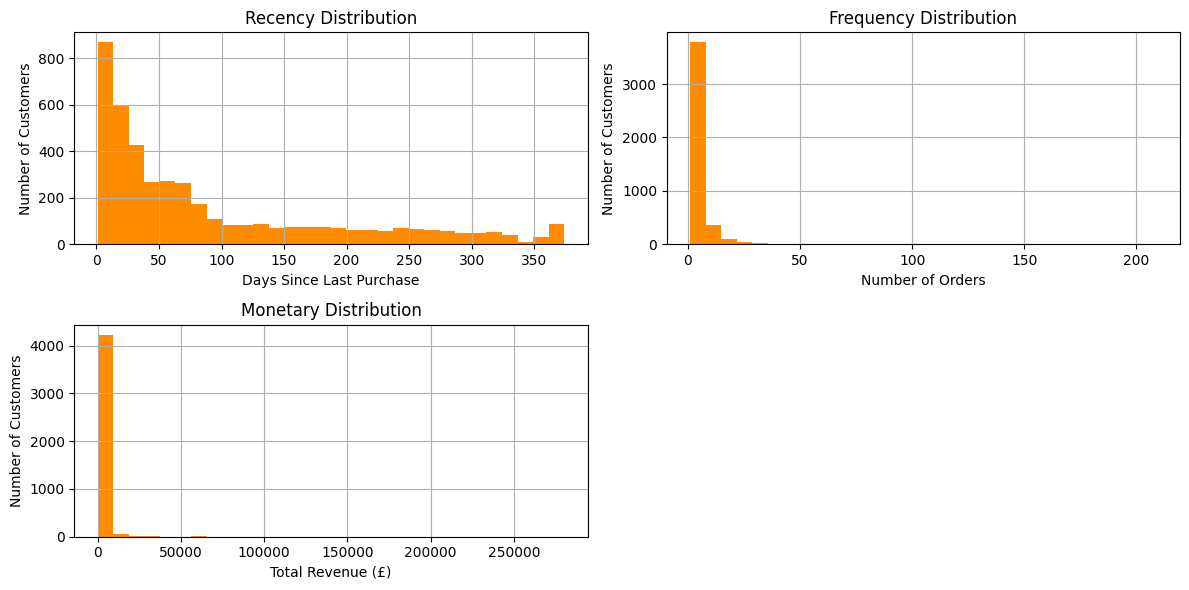

In [26]:
axes=rfm.hist(bins=30, figsize=(12,6), color='darkorange', grid=True)   

axes[0,0].set_title("Recency Distribution")
axes[0,0].set_xlabel("Days Since Last Purchase")
axes[0,0].set_ylabel("Number of Customers")

axes[0,1].set_title("Frequency Distribution")
axes[0,1].set_xlabel("Number of Orders")
axes[0,1].set_ylabel("Number of Customers")

axes[1,0].set_title("Monetary Distribution")
axes[1,0].set_xlabel("Total Revenue (£)")
axes[1,0].set_ylabel("Number of Customers")

plt.tight_layout()


In [27]:
fig= px.scatter_3d(rfm, x=np.log1p(rfm['Recency']), y="Frequency", z=np.log1p(rfm['Monetary']), size=np.log1p(rfm['Monetary']), size_max=20,
                   labels={'x': 'Recency (log scale)', 'y': 'Frequency (log scale)', 'z': 'Monetary (log scale)'}, 
                   title='3D Scatter Plot of RFM Clusters', width=800, height=600) # Create a 3D scatter plot of the RFM clusters
fig.show() # Display the plot

# 7. Feature Transformation & Scaling

### Select model features

In [28]:
rfm_model = rfm[[ 'Recency', 'Frequency', 'Monetary' ]].copy() # Create a copy of the RFM dataset for modeling

### Log transformation (to reduce skewness)

In [29]:
rfm_log = rfm_model.copy() # Create a copy of the RFM dataset for log transformation
rfm_log[['Recency', 'Frequency', 'Monetary']] = np.log1p(rfm_log[['Recency', 'Frequency', 'Monetary']]) # Apply log transformation

RFM variables are highly right-skewed, especially Monetary. A log transformation reduces the effect of extreme values while retaining legitimate high-value customers.

### Standardization

In [30]:
scalar = StandardScaler() # Create a StandardScaler object
rfm_scaled = scalar.fit_transform(rfm_log) # Scale the log-transformed RFM features
rfm_scaled

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       ...,
       [-1.21893976, -0.36158278, -1.11333158],
       [-1.65755161,  2.17800394,  0.82281217],
       [-0.03473174,  0.05960547,  0.73752572]], shape=(4338, 3))

The transformed features are then standardized so that Recency, Frequency and Monetary contribute on comparable scales to the distance-based K-Means algorithm.

In [31]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary']) # Create a DataFrame for scaled RFM features
rfm_scaled_df.head() 

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


# 8. Selecting the Number of Clusters

### Evaluation

In [32]:
# Evaluate Candidate Cluster Counts
inertia = []
silhouette_scores = []
davies_bouldin_indices = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++') # Create a KMeans object with k clusters
    kmeans.fit(rfm_scaled_df) # Fit the KMeans model to the scaled RFM features
    inertia.append(kmeans.inertia_) # Append the inertia value to the list
    silhouette_scores.append(silhouette_score(rfm_scaled_df, kmeans.labels_)) # Append the silhouette score to the list
    davies_bouldin_indices.append(davies_bouldin_score(rfm_scaled_df, kmeans.labels_)) # Append the Davies-Bouldin index to the list

### Elbow, Silhouette and Davies-Bouldin Analysis

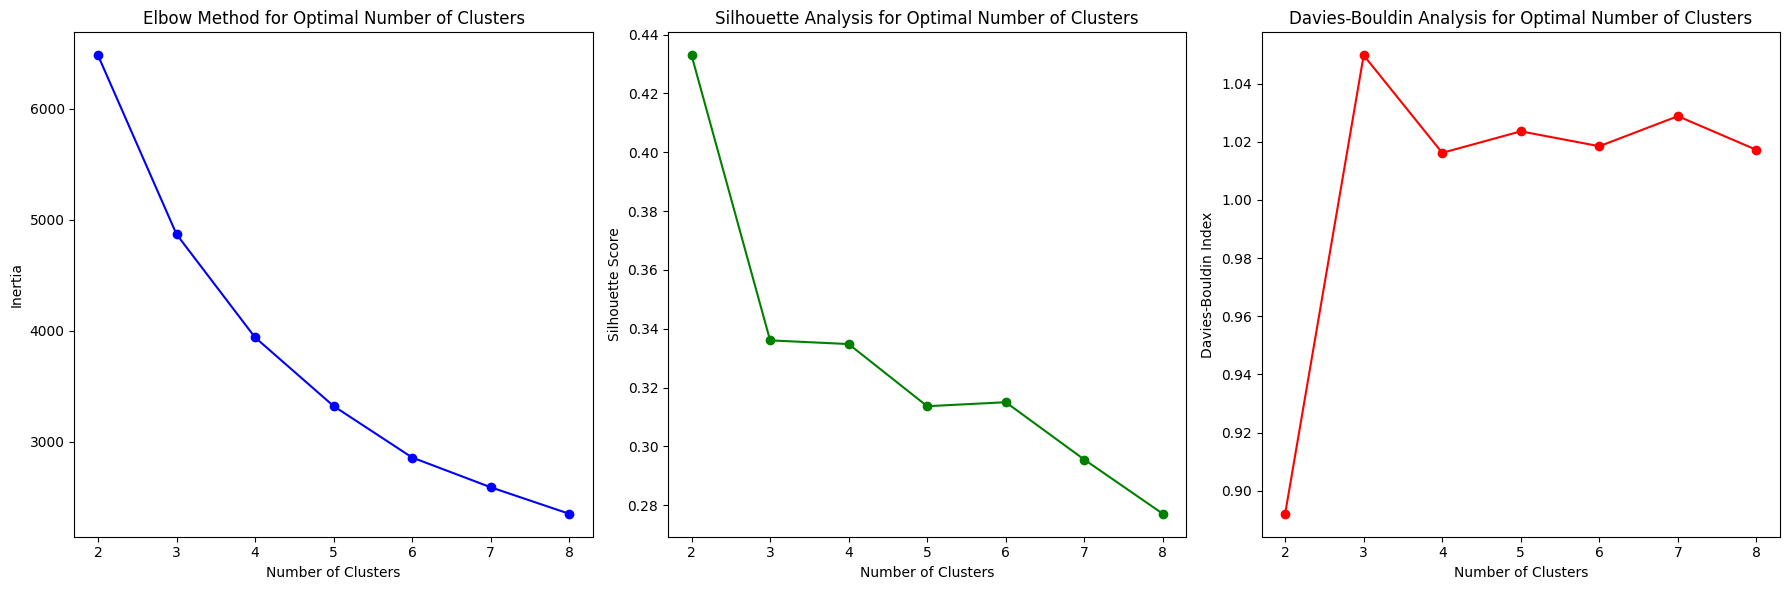

In [33]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.plot(range(2, 9), inertia, marker='o', color='blue') # Plot the inertia values against the number of clusters
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')

plt.subplot(1,3,2)
plt.plot(range(2, 9), silhouette_scores, marker='o', color='green') # Plot the silhouette scores against the number of clusters
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal Number of Clusters')

plt.subplot(1,3,3)
plt.plot(range(2, 9), davies_bouldin_indices, marker='o', color='red') # Plot the Davies-Bouldin indices against the number of clusters
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Analysis for Optimal Number of Clusters')

plt.tight_layout()
plt.show()


Based on the elbow pattern, silhouette analysis and Davies-Bouldin index, **K = 3** was selected for the final segmentation. k=3 gives the highest Silhouette score among the practical candidates and a relatively low Davies–Bouldin index, while the elbow plot shows a clear reduction in marginal improvement after k=3.

# 9. K-Means Customer Segmentation

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42) # Create a KMeans object with 3 clusters
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df) # Fit the KMeans model and predict the cluster labels

In [35]:
rfm.describe() # Display the statistical summary of the RFM dataset with cluster labels

,Recency,Frequency,Monetary,Cluster
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,0.959659
std,100.014169,7.697998,8985.230220,0.905488
min,1.000000,1.000000,3.750000,0.000000
25%,18.000000,1.000000,306.482500,0.000000
50%,51.000000,2.000000,668.570000,1.000000
75%,142.000000,5.000000,1660.597500,2.000000
max,374.000000,209.000000,280206.020000,2.000000


### Cluster Profiling

In [36]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median() # Calculate the median RFM values for each cluster
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,159.0,1.0,295.00
1,9.0,10.0,3692.28
2,30.0,3.0,968.81


### Customer distribution across each profile

In [37]:
rfm['Cluster'].value_counts()

Cluster
0    1869
2    1694
1     775
Name: count, dtype: int64

In [38]:
#rank = cluster_profile['Monetary'].rank(ascending=True).astype(int)

r_rank = cluster_profile['Recency'].rank(ascending=True)   # lowest Recency = better rank
f_rank = cluster_profile['Frequency'].rank(ascending=False) # highest Frequency = better rank
m_rank = cluster_profile['Monetary'].rank(ascending=False) # highest Monetary = better rank

cluster_profile['Composite_Rank'] = r_rank + f_rank + m_rank

cluster_profile["Value_rank"] = cluster_profile["Composite_Rank"].rank(ascending=True, method="first").astype(int)

label_by_rank = {1: 'High-Value / Loyal', 2: 'Mid-Value / Potential', 3: 'Low-Value / At Risk'}
cluster_labels = cluster_profile['Value_rank'].map(label_by_rank).to_dict()
cluster_labels

{0: 'Low-Value / At Risk', 1: 'High-Value / Loyal', 2: 'Mid-Value / Potential'}

Cluster labels are derived from the relative RFM profile of each cluster rather than being hardcoded to specific cluster numbers.

Recency is ranked with lower values preferred, while Frequency and Monetary are ranked with higher values preferred. The combined ranking is then used to assign business-oriented segment labels.

In [39]:
rfm['Cluster_label'] = rfm['Cluster'].map(cluster_labels) # Map the cluster labels to the RFM dataset
cluster_profile['Cluster_label']=cluster_profile.index.map(cluster_labels)
cluster_profile

,Recency,Frequency,Monetary,Composite_Rank,Value_rank,Cluster_label
Cluster,,,,,,
0,159.0,1.0,295.00,9.0,3,Low-Value / At Risk
1,9.0,10.0,3692.28,3.0,1,High-Value / Loyal
2,30.0,3.0,968.81,6.0,2,Mid-Value / Potential


### Customer distribution by cluster label

In [40]:
rfm['Cluster_label'].value_counts(normalize=True)*100 

Cluster_label
Low-Value / At Risk      43.084371
Mid-Value / Potential    39.050254
High-Value / Loyal       17.865376
Name: proportion, dtype: float64

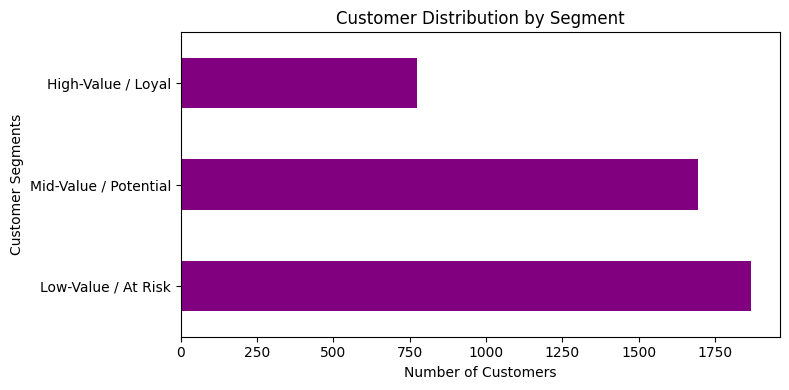

In [41]:
rfm['Cluster_label'].value_counts().plot(kind='barh', figsize=(8,4), color='purple') # Plot the distribution of clusters
plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segments")
plt.tight_layout()
plt.show()

In [42]:
rfm.head() # Display the first five rows of the RFM model dataset

,Recency,Frequency,Monetary,Cluster,Cluster_label
CustomerID,,,,,
12346.0,326,1,77183.60,2,Mid-Value / Potential
12347.0,2,7,4310.00,1,High-Value / Loyal
12348.0,75,4,1797.24,2,Mid-Value / Potential
12349.0,19,1,1757.55,2,Mid-Value / Potential
12350.0,310,1,334.40,0,Low-Value / At Risk


### Customer Segment Visualization

In [43]:
fig= px.scatter_3d(rfm, x=np.log1p(rfm['Recency']), y="Frequency", z=np.log1p(rfm['Monetary']), 
                   color=rfm['Cluster_label'], size=np.log1p(rfm['Monetary']), size_max=20,
                   labels={'x': 'Recency (log scale)', 'y': 'Frequency (log scale)', 'z': 'Monetary (log scale)'}, 
                   title='3D Scatter Plot of RFM Clusters', width=800, height=600) # Create a 3D scatter plot of the RFM clusters
fig.show() # Display the plot

# 10. Customer Segment Profiles

In [44]:
segment_profile = rfm.groupby("Cluster_label").agg(
    Customers=("Recency", "count"),
    Recency=("Recency", "median"),
    Frequency=("Frequency", "median"),
    Monetary=("Monetary", "median"),
    Total_Revenue=("Monetary", 'sum')

)

segment_profile["Customer_%"] = (segment_profile["Customers"] / len(rfm) * 100).round(1)
segment_profile["Revenue_Share%"]= (segment_profile["Total_Revenue"]/segment_profile["Total_Revenue"].sum() * 100).round(1)


segment_profile

,Customers,Recency,Frequency,Monetary,Total_Revenue,Customer_%,Revenue_Share%
Cluster_label,,,,,,,
High-Value / Loyal,775,9.0,10.0,3692.28,6090749.620,17.9,68.5
Low-Value / At Risk,1869,159.0,1.0,295.00,673625.481,43.1,7.6
Mid-Value / Potential,1694,30.0,3.0,968.81,2122833.793,39.1,23.9


# 11. Business Insights and Actions

**High-Value / Loyal**

Insight:
Recent, frequent and high-spending customers contributing disproportionately to revenue. 17.9% of customers making up 68.5% of the total revenue.

Action:
Prioritize retention through loyalty benefits, exclusive offers, early access and personalized recommendations.



**Mid-Value / Potential**

Insight:
39.1% of customers contributing 23.9% of revenue with moderate recency, frequency and spending

Action:
Use personalized offers, bundles and cross-selling to encourage repeat purchases.



**Low-Value / At Risk**

Insight:
Customers with low purchase frequency, lower spending and longer periods since their last purchase. 43.1% of customers contribute only 7.6% of total revenue. 

Action:
Use targeted re-engagement and win-back campaigns.


# 12. Save Model and Processed Data

In [45]:
MODEL_DIR =Path("../app")

# Save the KMeans model and scaler to the model directory
jl.dump(kmeans, MODEL_DIR / "kmeans_model.pkl")
jl.dump(scalar, MODEL_DIR / "scaler.pkl")
jl.dump(cluster_labels, MODEL_DIR / "cluster_labels.pkl")

df.to_csv("../data/Online_Retail_Cleaned.csv", index=False) # Save the cleaned DataFrame to a new CSV file in the processed data directory

rfm[['Recency','Frequency','Monetary']].to_csv("../data/customer_rfm.csv", index=True)


# 13. Conclusion

This project used K-Means clustering to identify 3 distinct customer segments based on purchasing behavior.

RFM features provided a compact representation of customer behavior while log transformation and standardization prepared the features for distance-based clustering.

The final clusters were evaluated using multiple internal validation measures and profiled using customer-level purchasing behavior. Rather than relying on arbitrary K-Means cluster IDs, business labels were derived from the resulting cluster profiles.

The segmentation provides a practical framework for differentiated customer retention, engagement and reactivation strategies.

The fitted model and preprocessing pipeline were saved for deployment in a Streamlit application.

# Appendix

The following analysis is supplementary to the main K-Means segmentation. It demonstrates a traditional RFM scoring approach and compares its customer classifications with the machine-learning clusters.

### Traditional RFM Scoring

Here customers are scored independtly on Recency, Frequency and Monetary values using quintiles. 

Each feature is assigned a score from 1-5:
- Recency: lower values receive higher scores.
- Frequency: higher values receive higher scores.
- Monetary: higher values receieve higher scores.

The three scores are combined into an overall RFM score which is used to segmentize the customers into Low, Mid and High value groups.


In [46]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]) # Recency scores
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]) # Frequency scores
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]) # Monetary scores
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str) # Combined RFM score
rfm['RFM_score'] = rfm[['R_score', 'F_score', 'M_score']].sum(axis=1) # Total RFM score
rfm.head()

,Recency,Frequency,Monetary,Cluster,Cluster_label,R_score,F_score,M_score,RFM_segment,RFM_score
CustomerID,,,,,,,,,,
12346.0,326,1,77183.60,2,Mid-Value / Potential,1,1,5,115,7
12347.0,2,7,4310.00,1,High-Value / Loyal,5,5,5,555,15
12348.0,75,4,1797.24,2,Mid-Value / Potential,2,4,4,244,10
12349.0,19,1,1757.55,2,Mid-Value / Potential,4,1,4,414,9
12350.0,310,1,334.40,0,Low-Value / At Risk,1,1,2,112,4


### Distribution across each RFM score

In [47]:
rfm['RFM_score'].value_counts().sort_index()

RFM_score
3     183
4     361
5     337
6     426
7     377
8     375
9     336
10    342
11    347
12    321
13    286
14    300
15    347
Name: count, dtype: int64

In [48]:
rfm['RFM_label'] = pd.qcut(rfm['RFM_score'], q=3, labels=['Low-Value', 'Mid-Value', 'High-Value']) # Assign RFM level based on RFM score using quantiles

In [49]:
rfm['RFM_label'].value_counts(normalize=True)*100 # Display the distribution of RFM levels in percentage

RFM_label
Low-Value     38.819733
Mid-Value     32.272937
High-Value    28.907331
Name: proportion, dtype: float64

The rule based RFM approach produced a relatively balanced distribution of three customer groups as expected from quintile based scoring.

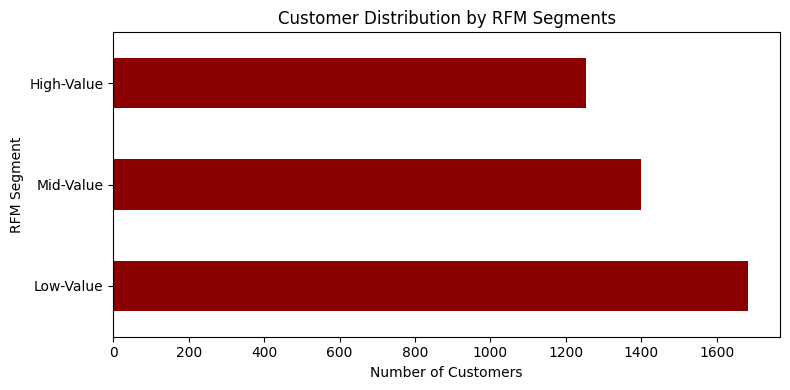

In [50]:
rfm['RFM_label'].value_counts().plot(kind='barh', figsize=(8,4), color='darkred') # Plot the distribution of RFM levels
plt.title("Customer Distribution by RFM Segments")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")
plt.tight_layout()
plt.show()

In [51]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Cluster_label,R_score,F_score,M_score,RFM_segment,RFM_score,RFM_label
CustomerID,,,,,,,,,,,
12346.0,326,1,77183.60,2,Mid-Value / Potential,1,1,5,115,7,Low-Value
12347.0,2,7,4310.00,1,High-Value / Loyal,5,5,5,555,15,High-Value
12348.0,75,4,1797.24,2,Mid-Value / Potential,2,4,4,244,10,Mid-Value
12349.0,19,1,1757.55,2,Mid-Value / Potential,4,1,4,414,9,Mid-Value
12350.0,310,1,334.40,0,Low-Value / At Risk,1,1,2,112,4,Low-Value


In [52]:
segment_profile = (rfm.groupby('RFM_label')[['Recency','Frequency', 'Monetary']].median())
segment_profile

,Recency,Frequency,Monetary
RFM_label,,,
Low-Value,169.0,1.0,264.270
Mid-Value,45.5,3.0,727.950
High-Value,12.0,7.0,2550.225


### RFM vs Kmeans

The traditional RFM segments are compared with Kmeans segments to see how closely the two approaches classify customers.


In [53]:
pd.crosstab(rfm['RFM_label'], rfm['Cluster_label'], normalize='index')*100 # Create a cross-tabulation of RFM levels and cluster labels

Cluster_label,High-Value / Loyal,Low-Value / At Risk,Mid-Value / Potential
RFM_label,,,
Low-Value,0.000000,97.030879,2.969121
Mid-Value,0.428571,16.785714,82.785714
High-Value,61.323764,0.000000,38.676236


The two approaches show strong agreement especially in the case of Low-Value and Mid-Value groups. High Value RFM segment also agrees substantially with K-means segments.

Traditional RFM scoring gives interpretable rule based customer groups while kmeans provides naturally occurring groups from the RFM features. The strong overlap between the approaches confirms the resulting segmentations.
